# Ambika Gole : 48623857

## In this portfolio task I will analyse the data from data.csv which is a dataset about Breast cancer diagnosis to predict whether the cancer is benign or malignant

Since this is a real world dataset that has data regading abreast cancer type. In this analysis wewill try and build a model which can predict whether a cancer is Benign or Malignant accurately using the given different features.

In [881]:
#Importing required python libraries
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")


The dataset was found on kaggle after careful consideration and going through the data. i have decided this is a perfect dataset for my needs of building two predictive models.
The link to the dataset is as follow: [link](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data)

In [883]:
#Importing data set
df = pd.read_csv('data/data.csv')

#Printing first 15 rows of data set
df.head(15)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,NaN


## Cleaning the Data for exploration

In this section I will explore the data by cleaning up the missing values even though the original data looks clean. It is generally recommended to clean datasets even though you are sure it is clean to ensure you get a better and more accurate model and analysis.

In [886]:
#Dropping the missing values
df.dropna()

#Removing 'id' column
df = df.drop('id', axis = 1)

# Drop the column named 'Unnamed'
df= df.drop(columns=['Unnamed: 32'], errors='ignore')

After cleaning the dataset a little bit, I am going ahead and replacing the M that stands for malignant with 1 and B that stands for benign with 0 so that we can use this as out dependent variable.

In [888]:
# Encoding benign as 0 and malignant as 1
#pd.set_option('future.no_silent_downcasting', True)
df['diagnosis'] = df['diagnosis'].replace({'M' : 1, 'B' : 0})

# Reset warnings to default behavior (optional)
warnings.filterwarnings("default")

#Printing the updated dataset
df.head(15)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678
5,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440
6,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368
7,1,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510
8,1,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720
9,1,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750


## Exploring the dataset

In this section I will explore and examine to see whether the data set has some relation between different variables or not. I will try and find the features which have the most correlation to our dependant variable. 

In [891]:
# Calculate correlations
df.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


Since we have a lot of columns, we are going to keep the 10 most correlated features against Diagnosis and drop the other columns for easing computation requirements for visualising the data.

In [893]:
# Get the absolute correlation values of features against 'diagnosis'
corr_with_diagnosis = correlation_matrix['diagnosis'].abs()

In [894]:
# Sorting and select the top 10 correlated features
sorted_features = corr_with_diagnosis.nlargest(11)  # 10 features + diagnosis
new_features = sorted_features.index.tolist()

# Filter the DataFrame to keep only the top correlated features
filtered_df = df[new_features]

In [895]:
filtered_df.head()

,diagnosis,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,concavity_mean,concavity_worst
0,1,0.2654,184.60,0.14710,25.38,122.80,2019.0,17.99,1001.0,0.3001,0.7119
1,1,0.1860,158.80,0.07017,24.99,132.90,1956.0,20.57,1326.0,0.0869,0.2416
2,1,0.2430,152.50,0.12790,23.57,130.00,1709.0,19.69,1203.0,0.1974,0.4504
3,1,0.2575,98.87,0.10520,14.91,77.58,567.7,11.42,386.1,0.2414,0.6869
4,1,0.1625,152.20,0.10430,22.54,135.10,1575.0,20.29,1297.0,0.1980,0.4000


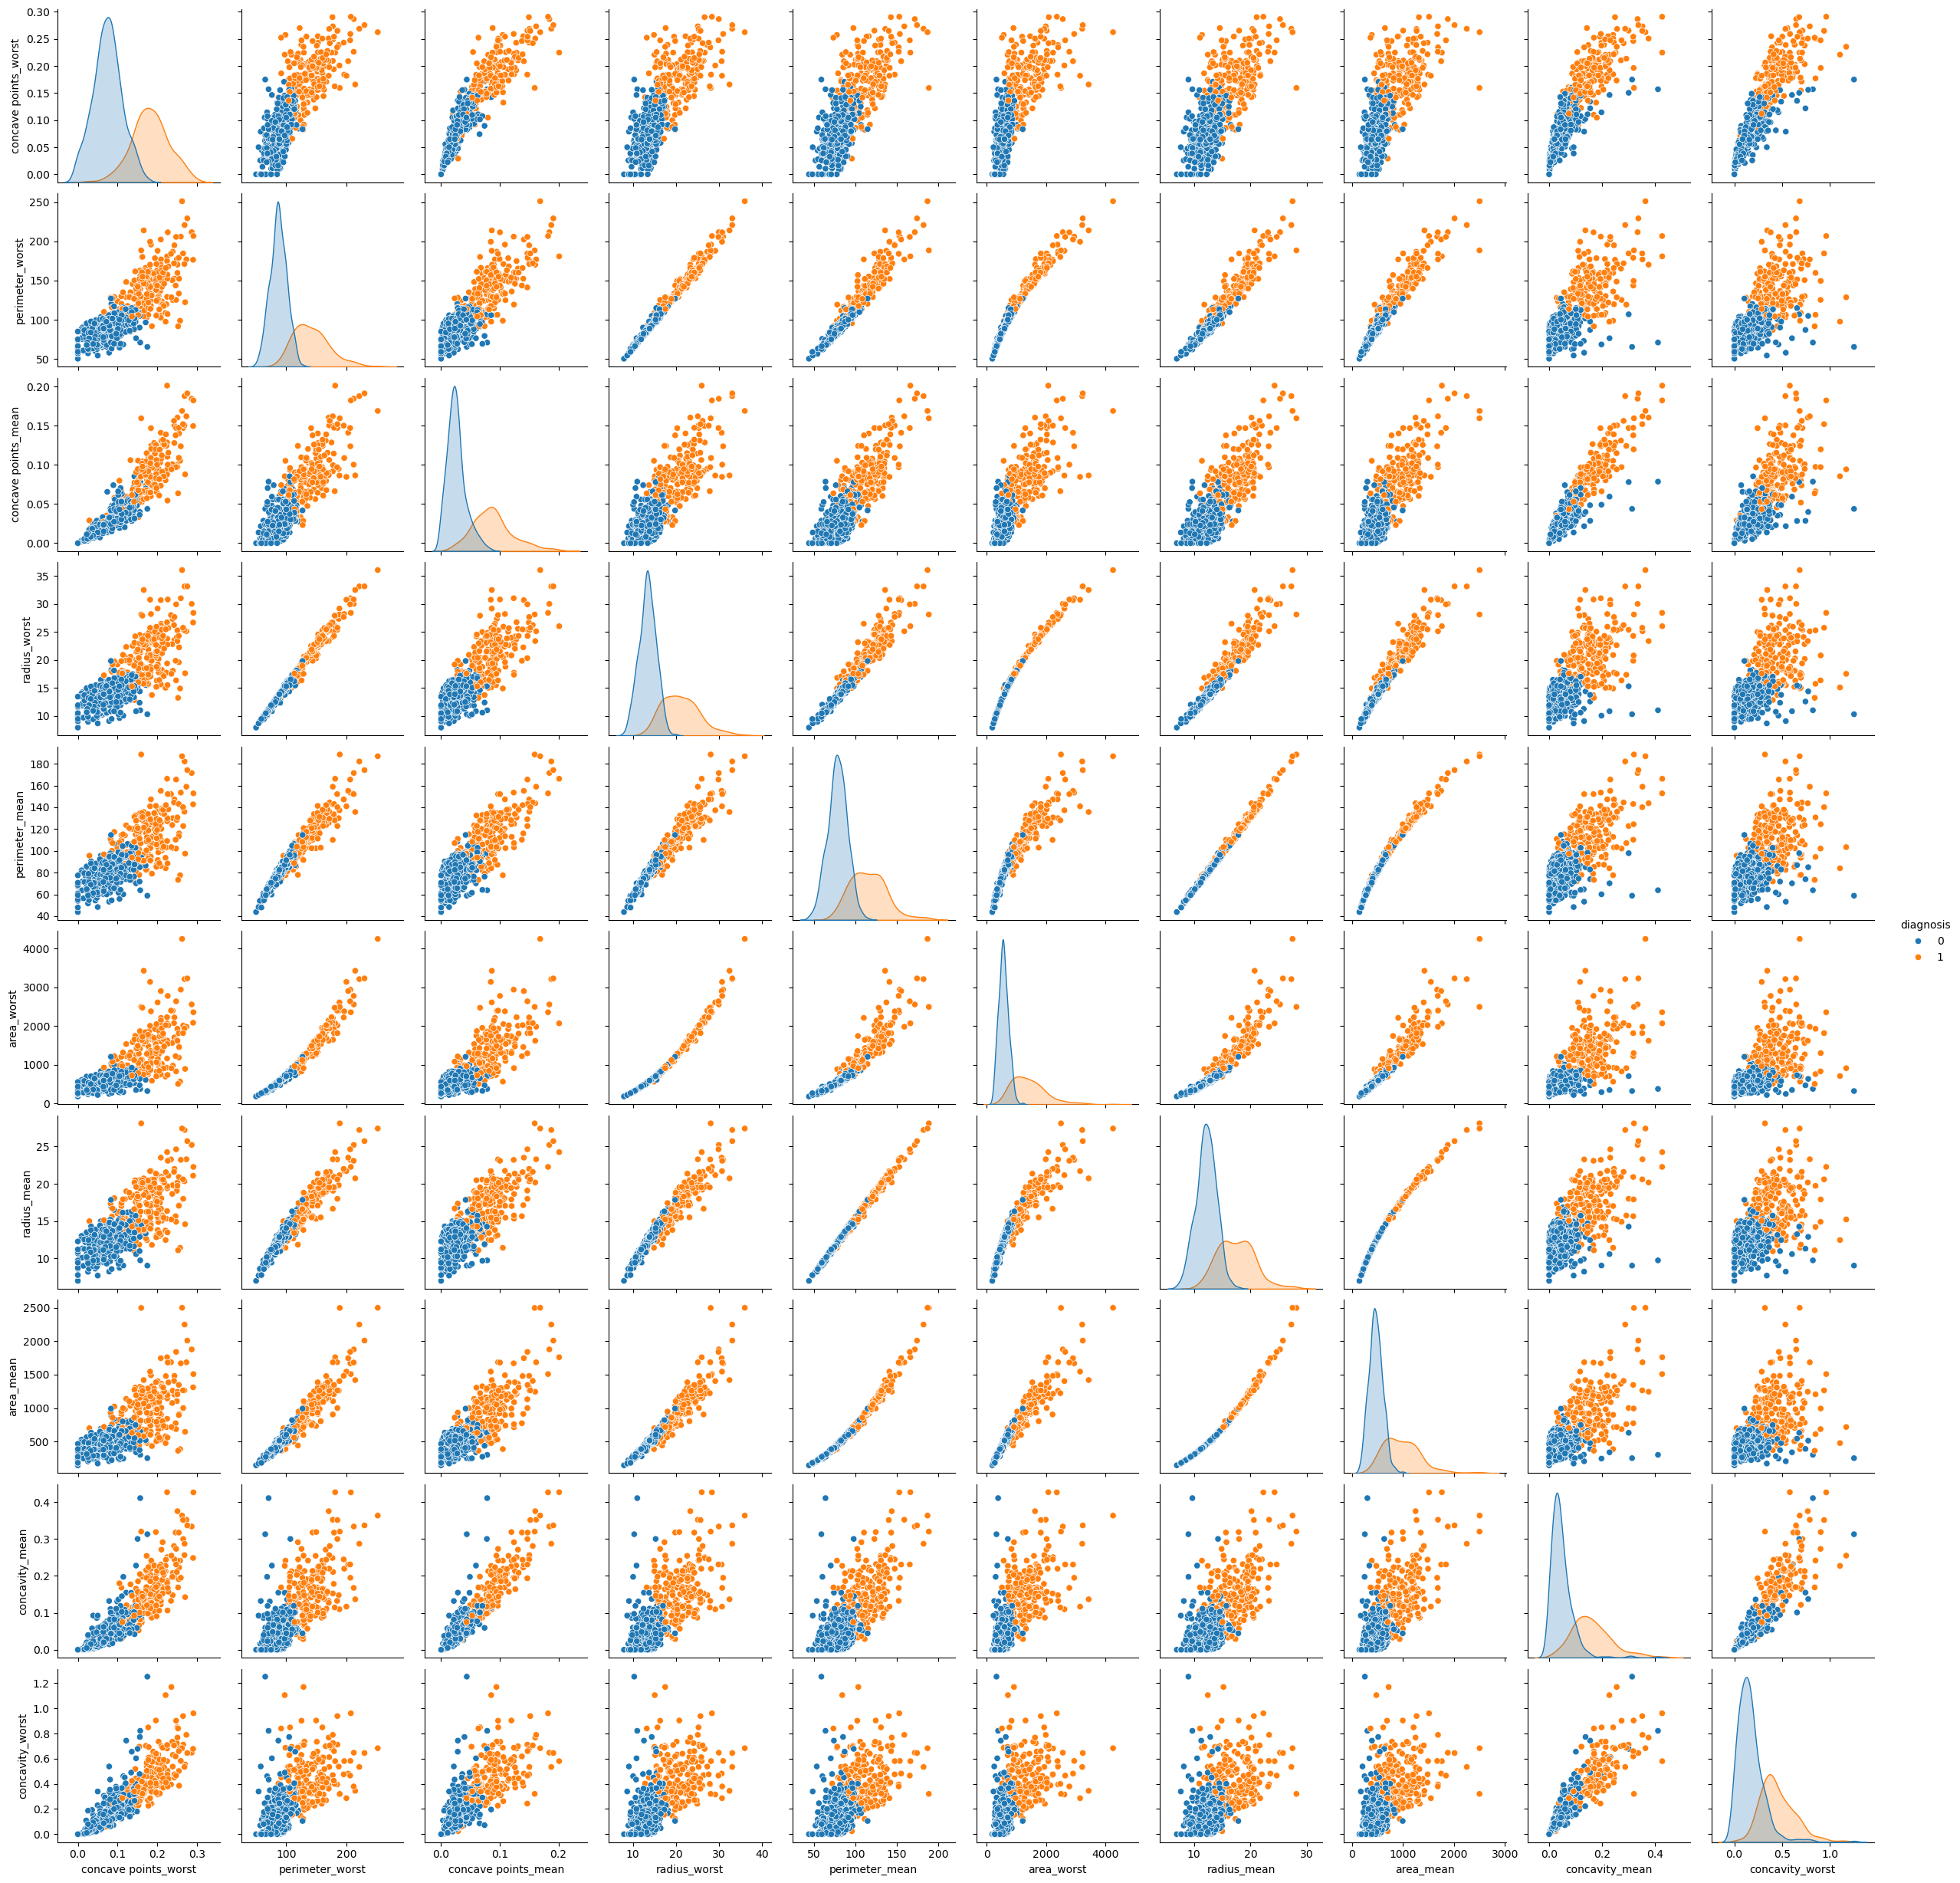

In [896]:
#plotting a Pairplot to visualise relationships of different features
sns.pairplot(filtered_df, hue='diagnosis')

In [897]:
#getting correlation to find the feature which highest correlation to diagnosis
filtered_df.corr()

,diagnosis,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,concavity_mean,concavity_worst
diagnosis,1.000000,0.793566,0.782914,0.776614,0.776454,0.742636,0.733825,0.730029,0.708984,0.696360,0.659610
concave points_worst,0.793566,1.000000,0.816322,0.910155,0.787424,0.771241,0.747419,0.744214,0.722017,0.861323,0.855434
perimeter_worst,0.782914,0.816322,1.000000,0.855923,0.993708,0.970387,0.977578,0.965137,0.959120,0.729565,0.618344
concave points_mean,0.776614,0.910155,0.855923,1.000000,0.830318,0.850977,0.809630,0.822529,0.823269,0.921391,0.752399
radius_worst,0.776454,0.787424,0.993708,0.830318,1.000000,0.969476,0.984015,0.969539,0.962746,0.688236,0.573975
perimeter_mean,0.742636,0.771241,0.970387,0.850977,0.969476,1.000000,0.941550,0.997855,0.986507,0.716136,0.563879
area_worst,0.733825,0.747419,0.977578,0.809630,0.984015,0.941550,1.000000,0.941082,0.959213,0.675987,0.543331
radius_mean,0.730029,0.744214,0.965137,0.822529,0.969539,0.997855,0.941082,1.000000,0.987357,0.676764,0.526911
area_mean,0.708984,0.722017,0.959120,0.823269,0.962746,0.986507,0.959213,0.987357,1.000000,0.685983,0.512606
concavity_mean,0.696360,0.861323,0.729565,0.921391,0.688236,0.716136,0.675987,0.676764,0.685983,1.000000,0.884103


From the above correlation result, concave points_worst is the most correlated with diagnosis in comparision to others with a score 0.793566. The feature is representative of the highest number of portions of the contour in the cancerous tumor.


## Building Models

In this section I will build a logistic regression model taking concave points_worst and diagnosis and later will also perfom K-Nearest Neighbor.

## Logistic Regression

In [902]:
#Building a logistic regression as a baseline model 
log_reg = linear_model.LogisticRegression()
x = df[['concave points_worst']]
y = df ['diagnosis']
x_train, x_test, y_train , y_test = train_test_split(x,y, test_size = 0.1, random_state = 48623857)
log_reg.fit(x_train, y_train)

LogisticRegression()

After running a simple logistic regression I will now try and find the accuracy of the predicions of the Diagnosis using the train test split that was created above

In [904]:
#Calculating Accuracy of the Logistic Regression model
y_reg = log_reg.predict(x_test)
print("Accuracy of logistic regression classifier on test set: {:.2f}".format(log_reg.score(x_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.86


With a accuracy of 0.86, this indicates that for my logistic regression model, the model correctly predicts whether is a cancer is malignant or benign 86% of the time. 

In [906]:
#Calculating a confusion matrix
y_pred= log_reg.predict(x_test)
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[39  0]
 [ 8 10]]


The confusion matrix lets us find what type of perdicions our model predicted and what types of predictions our model predicted wrongly.
The first number in the martice  39 indicates that our matrix correctly predicted 39 instances as malignant correctly and had no false positives.

Following this, I look at the second part of the matrix where the model incorrectly predicted 8 instances as benign when the cancer was actually malignant. Finally, the model correctly predicted 10 instance where the cancer was malignant.

In [909]:
#Performing Accuracy test again and f1 score
accuracy_test = accuracy_score(y_test, y_pred)
f1_score_test = f1_score(y_test, y_pred)
print("Testing Accuracy:", accuracy_test)
print("Testing f1 score:", f1_score_test)

Testing Accuracy: 0.8596491228070176
Testing f1 score: 0.7142857142857143


The Accuracy score I have already explained earlier. Looking at the F1 score, a score of 0.71 reflects that like while my model is good at indentifying true positives, there is still room for improving the model

I have chosen KNN becuase its is frequently used in Medical diagnosis datasets similar to our Breast Cancer dataset. 

## K-Nearest Neighbors

In [913]:
#Preparing the data for K nearest neighbor by splitting it
x1_train, x1_test, y1_train, y1_test = train_test_split(x,y, test_size = 0.1, random_state = 48623857)

In [914]:
#Building a KNN model as our more complex model
clf = KNeighborsClassifier(n_neighbors = 1)
clf.fit(x1_train, y1_train)
y1_pred = clf.predict(x1_test)

#Calculating this models accuracy
accuracy = accuracy_score(y1_pred, y1_test)
print("Testing accuracy is:", accuracy)

Testing accuracy is: 0.8596491228070176


In [915]:
# Looping through 1 to 50 nearest neighbors to find the optimal number of neighbours or K value
training_error = list()
testing_error = list()

for i in range(1, 50):
    clf = KNeighborsClassifier(n_neighbors = i)
    clf.fit(x1_train, y1_train)
    training_error.append(1.0-accuracy_score(clf.predict(x1_train), y1_train))
    testing_error.append(1.0-accuracy_score(clf.predict(x1_test), y1_test))

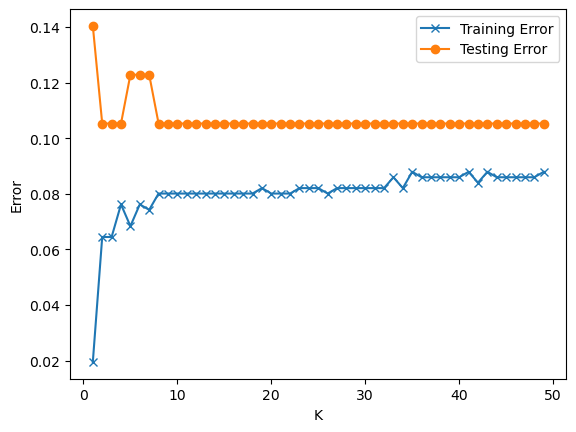

In [916]:
# Creating a plot to visualise the results
plt.plot(range(1,50), training_error, marker='x', label='Training Error')
plt.plot(range(1,50), testing_error, marker='o', label='Testing Error')
plt.xlabel('K')
plt.ylabel('Error')
plt.legend(loc='best')
plt.show()

This above plot helps us find the omptival value for K in my KNN algorithm. The x axis and y axis represents K value and Error respectively. The orange line is the Tesing error and the blue line is the training error. 
For the Training error, the error reamins fairly constant at around 0.08 it starts off at 0.02 but quickly rises up to 0.06 and stabilizes at 0.08.
For the Testing error, when K is close to 0, it is very high at 0.14  but decreases sharply as K increases then stablizes at around 0.10 when K value is around 10.

All in alll, we can see that the optimal value for K seems to be around 10.

In [918]:
# After estimating that 10 K value is most optimal running a accuracy test where nearest neighbours are 10
clf2 = KNeighborsClassifier(n_neighbors = 10)
clf2.fit(x1_train, y1_train)

y1_pred2 = clf.predict(x1_test)
accuracy = accuracy_score(y1_pred2, y1_test)
print("Testing accuracy is:", accuracy)

Testing accuracy is: 0.8947368421052632


After the above calculation of errrror and plotting, ran a KNN with 10 neighbors to see that the testing accuracy increases to 0.89 which means the model when K is 10 can predict if a canncer is malignant or benign 89% of the time.

# Conclusion
Finally, we can infer from our results that the highest number of Concavity Points in a cancerous tumor is a good indicator that the cancer is Malignant. However this model can be refined and made more accurate if we use the combination of multiple independent variables together to predict of a cancer is malignant or begnine. With the availability of larger datasets, we can also fine tune the model to have less false negatives.